<a href="https://colab.research.google.com/github/shibataryoma22-hub/-udemy/blob/main/udemy_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [3]:
x = torch.ones(2, 3, requires_grad=  True)
print(x)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)


In [5]:
y = x + 2
print(y)
print(y.grad_fn)

tensor([[3., 3., 3.],
        [3., 3., 3.]], grad_fn=<AddBackward0>)


In [7]:
a = torch.tensor([1.0], requires_grad= True)
b = a * 2
b.backward()
print(a.grad)

tensor([2.])


In [13]:
from math import e
def calc(a):
  b = a * 2 + 1
  c = b * b
  d = c / (c + 2)
  e = d.mean()
  return e
x = [1.0, 2.0, 3.0]
x = torch.tensor(x, requires_grad = True)

y = calc(x)
y.backward()
print(x.grad.tolist()) #xの勾配

[0.06611569225788116, 0.01828990876674652, 0.007176725193858147]


In [16]:
delta = 0.001 #xの微小変化

x = [1.0, 2.0, 3.0]
x = torch.tensor(x, requires_grad=True)
y = calc(x).item()

x_1 = [1.0+delta, 2.0, 3.0]
x_1 = torch.tensor(x_1, requires_grad=True)
y_1 = calc(x_1).item()

x_2 = [1.0, 2.0 + delta, 3.0]
x_2 = torch.tensor(x_2, requires_grad=True)
y_2 = calc(x_2).item()

x_3 = [1.0, 2.0, 3.0 + delta]
x_3 = torch.tensor(x_3, requires_grad=True)
y_3 = calc(x_3).item()


#勾配の計算
grad_x_1 = (y_1 - y) / delta
grad_x_2 = (y_2 - y) / delta
grad_x_3 = (y_3 - y) / delta

In [17]:
print(grad_x_1)
print(grad_x_2)
print(grad_x_3)

0.06604194641113281
0.018298625946044922
0.007152557373046875


In [2]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

In [25]:
#訓練データの取得
mnist_train = MNIST(root = './data',
                          train = True,
                          transform = transforms.ToTensor(),
                          download = True)
#テストデータの
mnist_test = MNIST(root = './data',
                          train = False,
                          transform = transforms.ToTensor(),
                          download = True)

In [26]:
print(mnist_train)

print(mnist_test)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [27]:
#DataLoader
img_size = 28
batch_size = 10
train_loader = DataLoader(mnist_train, batch_size = batch_size,
                          shuffle = True)
test_loader = DataLoader(mnist_test, batch_size = batch_size,
                          shuffle = False)

In [5]:
import torch.nn as nn
import torch.nn.functional as F

In [17]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(img_size * img_size, 1024)
    self.fc2 = nn.Linear(1024, 512)
    self.fc3 = nn.Linear(512, 10)

  def forward(self, x):
    x = x.view(-1, img_size * img_size)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


In [28]:
net = Net()
net.cuda()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [9]:
#学習
from torch import optim

In [10]:
#交差エントロピー誤差
loss_fnc = nn.CrossEntropyLoss()
#SGD
optimizer = optim.SGD(net.parameters(), lr = 0.01)


In [29]:
#損失のログ
record_loss_train = []
record_loss_test = []

#学習
for i in range(10):
  net.train()
  loss_train = 0
  for j, (x, t) in enumerate(train_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    loss = loss_fnc(y, t)
    loss_train += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  loss_train /= j+1
  record_loss_train.append(loss_train)

  net.eval()
  loss_test = 0
  for j, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    loss_fnc(y, t)
    loss_test += loss.item()
  loss_test /= j + 1
  record_loss_test.append(loss_test)

  if i%1 ==0:
    print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 2.307173601468404 Loss_Test: 2.314370632171631
Epoch: 1 Loss_Train: 2.307173604687055 Loss_Test: 2.2911384105682373
Epoch: 2 Loss_Train: 2.307173602859179 Loss_Test: 2.2851529121398926
Epoch: 3 Loss_Train: 2.307173604249954 Loss_Test: 2.3247907161712646
Epoch: 4 Loss_Train: 2.3071735990444817 Loss_Test: 2.30527925491333


KeyboardInterrupt: 

In [30]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

# 訓練データを取得
mnist_train = MNIST("./data",
                    train=True, download=True,
                    transform=transforms.ToTensor())
# テストデータの取得
mnist_test = MNIST("./data",
                   train=False, download=True,
                   transform=transforms.ToTensor())
print("訓練データの数:", len(mnist_train), "テストデータの数:", len(mnist_test))

# DataLoaderの設定
img_size = 28
batch_size = 256
train_loader = DataLoader(mnist_train,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(mnist_test,
                         batch_size=batch_size,
                         shuffle=False)

訓練データの数: 60000 テストデータの数: 10000


In [31]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, img_size*img_size)  # バッチサイズ×入力の数
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [33]:
# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(10):  # 10エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 1.12523663424431 Loss_Test: 0.8501023411750793
Epoch: 1 Loss_Train: 0.7380412553219085 Loss_Test: 0.6152376912534236
Epoch: 2 Loss_Train: 0.5738798429357245 Loss_Test: 0.5016237914562225
Epoch: 3 Loss_Train: 0.4888545931653773 Loss_Test: 0.43941347524523733
Epoch: 4 Loss_Train: 0.439397786906425 Loss_Test: 0.40087255351245404
Epoch: 5 Loss_Train: 0.40677665953940534 Loss_Test: 0.3746384158730507
Epoch: 6 Loss_Train: 0.3835432501549416 Loss_Test: 0.3551276385784149
Epoch: 7 Loss_Train: 0.36585697252699667 Loss_Test: 0.34048693580552936
Epoch: 8 Loss_Train: 0.3515932695662722 Loss_Test: 0.3278160773217678
Epoch: 9 Loss_Train: 0.3396401435770887 Loss_Test: 0.3167826129123569


In [34]:
import matplotlib.pyplot as plt

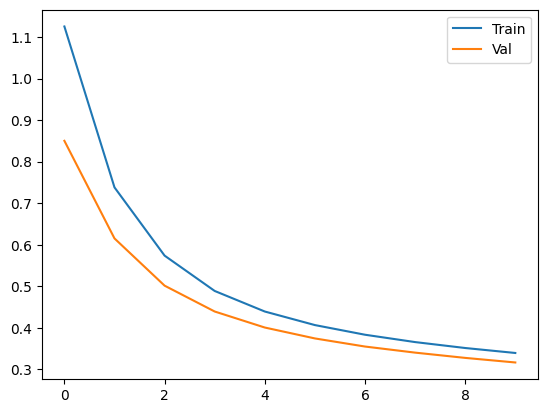

In [38]:
plt.plot(range(len(record_loss_train)), record_loss_train, label = "Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label = "Val")
plt.legend()
plt.show()